<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/02_task2_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Task 2 - Finetune
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

In [1]:
!rm -rf /content/TOL506M_Final_Project

In [2]:
import os, sys, subprocess, pathlib

REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# Always clone fresh in Colab
subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [3]:
import sys
import os
import subprocess
import importlib
import json
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import Counter
from PIL import Image
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Working directory: /content/TOL506M_Final_Project

PyTorch version: 2.8.0+cu126
CUDA available: True


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [5]:
# Import project modules
from config import Config
from data.dataset import (WildlifeDataset, SplitIndices, stratified_split,
                          compute_class_counts, materialize_split, is_italian,
                          translate_names, get_class_names, get_data_loaders)
from data.augmentation import get_train_transforms, get_val_transforms
from models.resnet_scratch import ResNet18Scratch
from tasks.task2 import fine_tune_pretrained
from utils.training import train_epoch, validate, EarlyStopping
from utils.evaluation import evaluate_model, get_confusion_matrix, compute_metrics
from utils.visualization import plot_training_curves, plot_confusion_matrix

data_fractions = Config.DATA_FRACTION
train_size = Config.TRAIN_SPLIT
val_size = Config.VAL_SPLIT
test_size = Config.TEST_SPLIT
random_seed = Config.RANDOM_SEED

data_path = Path(path) / 'raw-img'
Config.DATA_PATH = data_path

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Download and split dataset as previously done on previous notebooks
full_dataset = datasets.ImageFolder(root=str(data_path), transform=basic_transform)
dataset_transformed = translate_names(full_dataset)

wildlife = WildlifeDataset(str(data_path), transform=None)
train_idx_base, val_idx_fixed, test_idx_fixed = stratified_split(
    full_dataset,
    train_size=train_size,
    val_size=val_size,
    test_size=test_size,
    random_seed=random_seed
)

fixed = SplitIndices(train=train_idx_base, val=val_idx_fixed, test=test_idx_fixed)

print(f'Total images: {len(wildlife)}')
print(f'Base Train images: {len(train_idx_base)}')
print(f'Validation images: {len(val_idx_fixed)}')
print(f'Test images: {len(test_idx_fixed)}')

Total images: 26179
Base Train images: 18325
Validation images: 3927
Test images: 3927


In [6]:
# Create output dirs if they don't exist
Config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
Config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
Config.METRICS_DIR.mkdir(parents=True, exist_ok=True)

Training on 10 classes.
Training samples: 1832.
Validation samples: 3927.
Test samples: 3927.
Trainable parameters: 11,181,642/11,181,642


Validation: 100%|██████████| 123/123 [00:04<00:00, 24.71it/s]



 Epoch 1/50:
 Train Loss: 1.1725, Train Accuracy: 60.75%
 Val Loss: 1.2740, Val Accuracy: 57.47%
Saved best model (Val Acc: 57.47%).


Validation: 100%|██████████| 123/123 [00:04<00:00, 25.41it/s]



 Epoch 2/50:
 Train Loss: 0.7418, Train Accuracy: 77.46%
 Val Loss: 1.9602, Val Accuracy: 44.61%


...

Validation: 100%|██████████| 123/123 [00:04<00:00, 25.50it/s]



 Epoch 49/50:
 Train Loss: 0.0132, Train Accuracy: 99.95%
 Val Loss: 0.5512, Val Accuracy: 86.43%


Validation: 100%|██████████| 123/123 [00:04<00:00, 24.84it/s]


 Epoch 50/50:
 Train Loss: 0.0051, Train Accuracy: 99.84%
 Val Loss: 0.5235, Val Accuracy: 87.19%
Training completed in 498.79 seconds.



 Test Results: 
 Accuracy: 86.73%
 Precision: 86.92%
 Recall: 86.73%
 F1-score: 86.68%


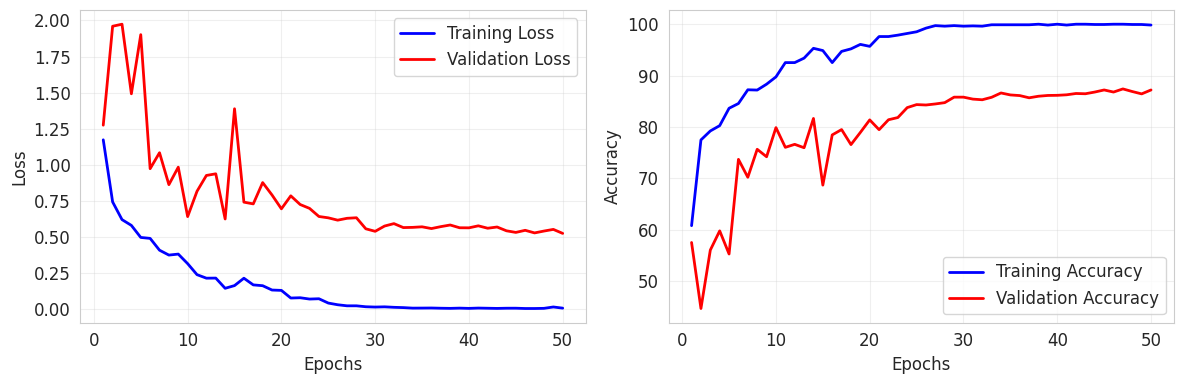

In [7]:
# Testing task2
frac = 0.1

train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=Config.RANDOM_SEED,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
)

result = fine_tune_pretrained(
        config=Config,
        data_fraction=frac,
        save_mode=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader
)

In [8]:
# Task 2: Fine-tune a pretrained ResNet model
all_results = []

for frac in data_fractions:
  print(f"\nStarting training for data fraction = {frac*100:.0f}%\n")

  train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(Config.DATA_PATH),
        batch_size=Config.BATCH_SIZE,
        num_workers=Config.NUM_WORKERS,
        train_split=Config.TRAIN_SPLIT,
        val_split=Config.VAL_SPLIT,
        test_split=Config.TEST_SPLIT,
        use_augmentation=Config.USE_AUGMENTATION,
        random_seed=Config.RANDOM_SEED,
        data_fraction=frac,
        fixed_indices=fixed,
        save_processed_root=str(Config.PROCESSED_DIR),
  )

  result = fine_tune_pretrained(
        config=Config,
        data_fraction=frac,
        save_mode=True,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader
  )

  all_results.append(result)

print("\nFinished training for all fractions.")


Starting training for data fraction = 10%


Starting training for data fraction = 25%


Starting training for data fraction = 50%


Starting training for data fraction = 75%


Starting training for data fraction = 100%


Finished training for all fractions.


In [9]:
# Save combined summary JSON
summary_path = Config.METRICS_DIR / "task2_finetune_summary.json"

with open(summary_path, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"Saved combined summary to {summary_path}")

Saved combined summary to /content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json


In [10]:
from IPython.display import Image, display

for frac in data_fractions:
    plot_path = Config.PLOTS_DIR / f"task2_finetune_learning_curves_{frac:.2f}.png"
    if plot_path.exists():
        print(f"\nLearning curves for fraction = {frac*100:.0f}%")
        display(Image(filename=str(plot_path)))
    else:
        print(f"Plot not found for fraction {frac:.2f}: {plot_path}")

Plot not found for fraction 0.10: /content/TOL506M_Final_Project/results/plots/task2_finetune_learning_curves_0.10.png
Plot not found for fraction 0.25: /content/TOL506M_Final_Project/results/plots/task2_finetune_learning_curves_0.25.png
Plot not found for fraction 0.50: /content/TOL506M_Final_Project/results/plots/task2_finetune_learning_curves_0.50.png
Plot not found for fraction 0.75: /content/TOL506M_Final_Project/results/plots/task2_finetune_learning_curves_0.75.png
Plot not found for fraction 1.00: /content/TOL506M_Final_Project/results/plots/task2_finetune_learning_curves_1.00.png


In [11]:
summary_path

PosixPath('/content/TOL506M_Final_Project/results/metrics/task2_finetune_summary.json')

In [12]:
Config.PLOTS_DIR

PosixPath('/content/TOL506M_Final_Project/results/plots')

In [13]:
!zip -r project.zip /content/TOL506M_Final_Project/

Streaming output truncated to the last 5000 lines.
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/OIP-H84zhgOoNSsMoqF0Yg0KxAHaEf.jpeg (deflated 1%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/OIP-mJk7YIf73EURZcxSEPd1wQHaE8.jpeg (deflated 1%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/e837b70b28f0003ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg (deflated 2%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/OIP-39kfp-3OpkoA_XYq31NAagHaEh.jpeg (deflated 1%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/OIP-sHKVkgqdawQawx7KJtYIQQHaD3.jpeg (deflated 2%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/val/elephant/OIP-B505mK4DHrIo6Ydescp6egHaFE.jpeg (deflated 1%)
  adding: content/TOL506M_Final_Project/data/processed/seed7278_data_frac10/va

In [14]:
from google.colab import files
files.download("project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>